# Principal Component Analysis From Scratch

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
from PIL import Image

### PCA Calculation

#### Step 1: Normalize the data
Using Z-score normalization on each feature/column of data: 
$$\tilde{x}_j = \frac{x_j - \mu_{col}}{\sigma_{col}}$$

#### Step 2: Compute the covariance matrix and eigenvectors
Covariance matrix: $$cm = \frac{1}{m-1}\tilde{X}^T\tilde{X}$$
Eigenvalues: $$det(cm - \lambda I) = 0 \rightarrow \lambda_j$$
Eigenvectors: $$(cm - \lambda I)v = 0 \rightarrow v_j$$
Normalized Eigenvectors: $$u_j = \tilde{X}^T \cdot v_j$$

#### Step 3: Reduce dimensionality (reducing features to the ones with the greatest variability)
$$D = \tilde{X} \cdot U_k$$
U_k being the reduced eigenvector

In [68]:
def pca(X, num_pc=2, std=False):
    '''
    Params:
        X - sample data
        num_pc - number of principal components to reduce down to
    Returns:
        D - reduced sample data
    '''

    if X.shape[1] < num_pc: 
        raise IndexError("num_pc is greater than the available features in the data")

    # step 1: normalize data
    mean = np.mean(X, axis=0)
    std_dev = np.std(X, axis=0)

    if std:
        std_dev[std_dev == 0] = 1
        Xtilde = (X - mean) / std_dev
    else:
        Xtilde = X - mean

    # step 2: compute covariance matrix and eigenvectors
    m, n = Xtilde.shape

    if n <= m:
        cov_matrix = Xtilde.T @ Xtilde
    else:
        cov_matrix = Xtilde @ Xtilde.T

    w, v = np.linalg.eigh(cov_matrix)
    
    if v.shape[0] == Xtilde.shape[0]:
        U = Xtilde.T @ v
    else:
        U = v

    U = U / np.linalg.norm(U, axis=0)

    # step 3: reduce dimensionality
    desc_indices = np.argsort(w)[::-1] # desc_indices is the indices of w sorted max to min
    w = w[desc_indices]
    U_k = U[:, desc_indices]
    
    D = Xtilde @ U_k[:, :num_pc]

    return D

### Testing

Tabular Data Test:

X shape:
(2148, 16)

D shape:
(2148, 2)


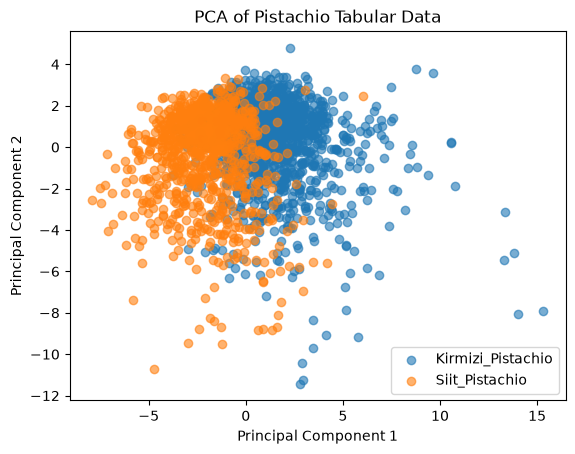

Image Data Test:

X shape:
(600, 4096)

D shape:
(600, 2)


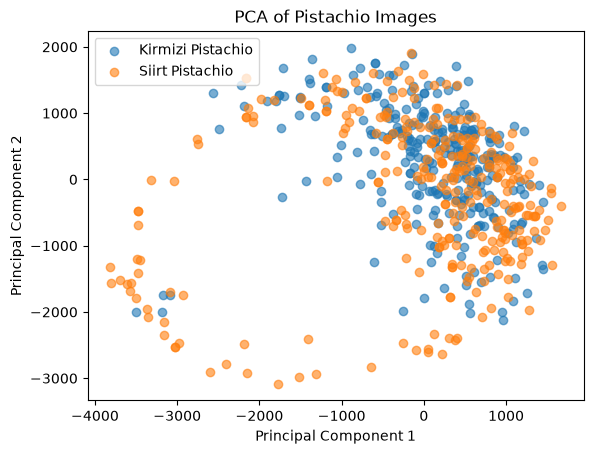

In [69]:
dataset_path = kagglehub.dataset_download("muratkokludataset/pistachio-image-dataset")

tabular_path = os.path.join(
    dataset_path,
    "Pistachio_Image_Dataset",
    "Pistachio_16_Features_Dataset",
    "Pistachio_16_Features_Dataset.xlsx"
)

kirmizi_path = os.path.join(
    dataset_path,
    "Pistachio_Image_Dataset",
    "Pistachio_Image_Dataset",
    "Kirmizi_Pistachio"
)

siirt_path = os.path.join(
    dataset_path,
    "Pistachio_Image_Dataset",
    "Pistachio_Image_Dataset",
    "Siirt_Pistachio"
)

df = pd.read_excel(tabular_path)

if "Class" in df.columns:
    Y = df["Class"].values
    X_raw = df.drop(columns=["Class"]).select_dtypes(include=[np.number]).values
else:
    Y = df.iloc[:, -1].values
    X_raw = df.iloc[:, :-1].select_dtypes(include=[np.number]).values

D = pca(X_raw, num_pc=2, std=True)

if isinstance(D, tuple):
    D = D[0]

print("Tabular Data Test:")

print("\nX shape:")
print(X_raw.shape)

print("\nD shape:")
print(D.shape)

for label in np.unique(Y):
    idx = Y == label
    plt.scatter(D[idx, 0], D[idx, 1], alpha=0.6, label=label)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Pistachio Tabular Data")
plt.legend()
plt.show()

def load_images(folder_path, label, image_size=(64, 64), max_images=300):
    image_files = sorted([
        os.path.join(folder_path, file)
        for file in os.listdir(folder_path)
        if file.lower().endswith(".jpg")
    ])

    image_files = image_files[:max_images]

    X_list = []
    Y_list = []

    for path in image_files:
        img = Image.open(path).convert("L")
        img = img.resize(image_size)
        img_array = np.array(img).astype(float)
        img_flat = img_array.flatten()

        X_list.append(img_flat)
        Y_list.append(label)

    return X_list, Y_list

X_kirmizi, Y_kirmizi = load_images(
    kirmizi_path,
    "Kirmizi_Pistachio",
    image_size=(64, 64),
    max_images=300
)

X_siirt, Y_siirt = load_images(
    siirt_path,
    "Siirt_Pistachio",
    image_size=(64, 64),
    max_images=300
)

X_raw = np.array(X_kirmizi + X_siirt)
Y = np.array(Y_kirmizi + Y_siirt)

D = pca(X_raw, num_pc=2)

if isinstance(D, tuple):
    D = D[0]

print("Image Data Test:")

print("\nX shape:")
print(X_raw.shape)

print("\nD shape:")
print(D.shape)

plt.scatter(
    D[Y == "Kirmizi_Pistachio", 0],
    D[Y == "Kirmizi_Pistachio", 1],
    alpha=0.6,
    label="Kirmizi Pistachio"
)

plt.scatter(
    D[Y == "Siirt_Pistachio", 0],
    D[Y == "Siirt_Pistachio", 1],
    alpha=0.6,
    label="Siirt Pistachio"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Pistachio Images")
plt.legend()
plt.show()